In [1]:
import numpy as np
import scipy.special as sp
import matplotlib.pyplot as plt
import geometric_phase_analysis_2D as gpa2D

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

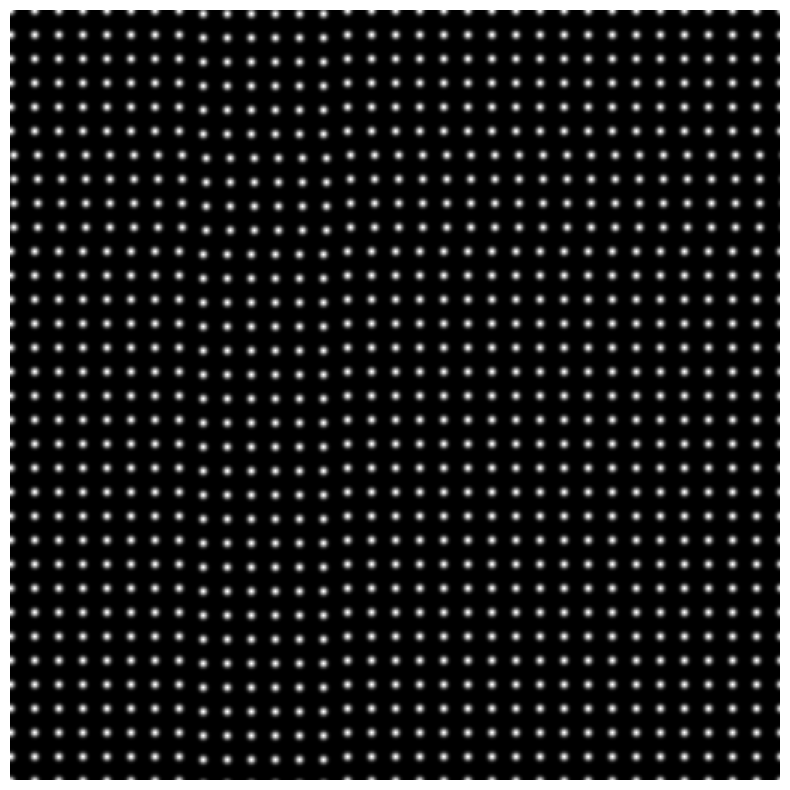

In [2]:
N = 512
im_view_plane = N//2
x = np.linspace(0,N-1, N)
[xx,yy] = np.meshgrid(x,x)
nSites_row = N//14
nSites_col = N//14
r = 2

a_rows = 16
a_cols = 16
coords = gpa2D.create_lattice(nSites_row,nSites_col,a_rows,a_cols)
nAtoms = coords.shape[0]

# Vertical shift
coords[288:501,1] = coords[288:501,1] + 2

# Horizontal shift
for i in range(6, 1280, 36):
    coords[i,0] = coords[i,0] + 2
for i in range(7, 1280, 36):
    coords[i,0] = coords[i,0] + 2
for i in range(8, 1280, 36):
    coords[i,0] = coords[i,0] + 2
for i in range(9, 1280, 36):
    coords[i,0] = coords[i,0] + 2


# Build simulated image by placing an error function at each coordinate
px, py = coords[:, 0], coords[:, 1]

sg = 2
totalVolume = np.zeros(xx.shape)

for i in range(px.shape[0]):
    rr = np.sqrt((xx-px[i])**2 + (yy-py[i])**2 )
    im = sp.erfc( (rr-r)/sg ) / 2 
    totalVolume = totalVolume + im

im = totalVolume
nx = N
ny = N

plt.figure(figsize = (10,10))
plt.imshow(im, cmap = 'gray')
plt.axis('off')

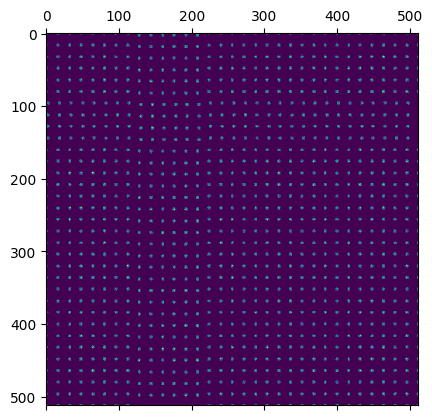

In [3]:
add_noise = True
noisy_im = np.random.poisson(im*100)
sigma = 2
noisy_im = noisy_im + np.random.normal(0, sigma, noisy_im.shape)
noisy_im = noisy_im - np.mean(noisy_im[:5,:5])
noisy_im[noisy_im<0] = 0
plt.matshow(noisy_im)
if add_noise:
    im = noisy_im

In [4]:
gpa_object = gpa2D.geometric_phase_analysis_2D(im)

In [5]:
diffraction_peaks = gpa_object.locate_diffraction_spots(25)
peakA, peakB = gpa_object.locate_first_order_peaks(diffraction_peaks)

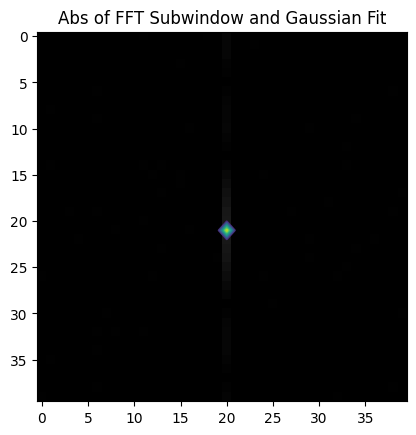

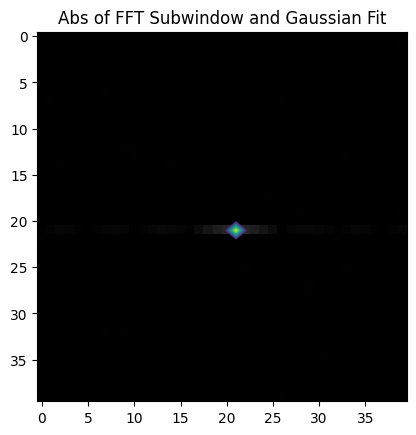

In [6]:
peakAPrecise = gpa_object.precise_peak_location(peakA)
peakBPrecise = gpa_object.precise_peak_location(peakB)

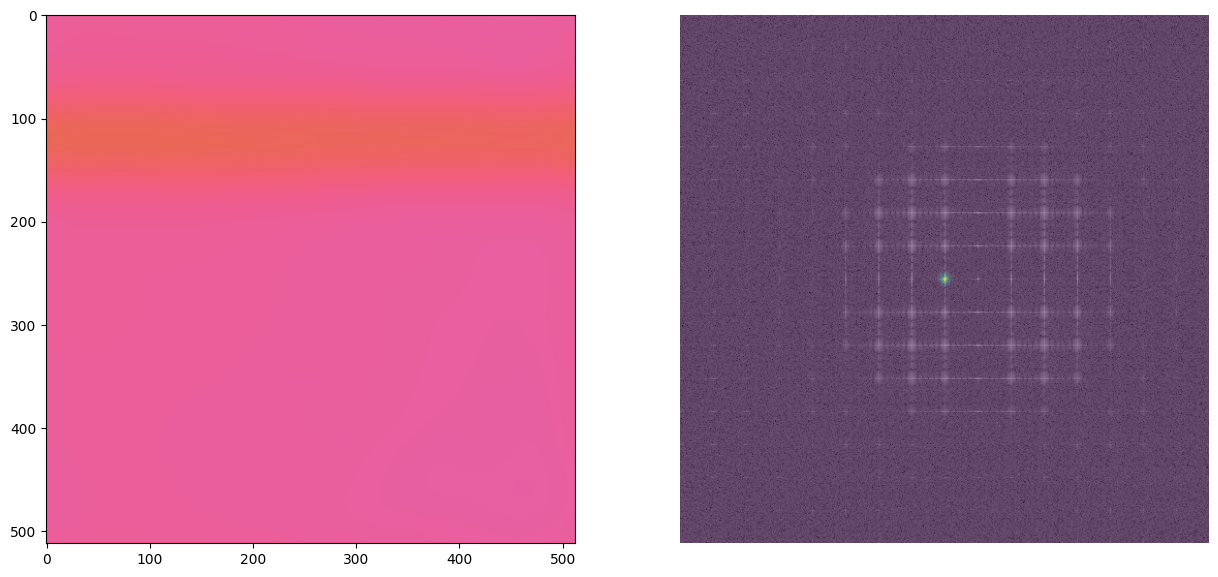

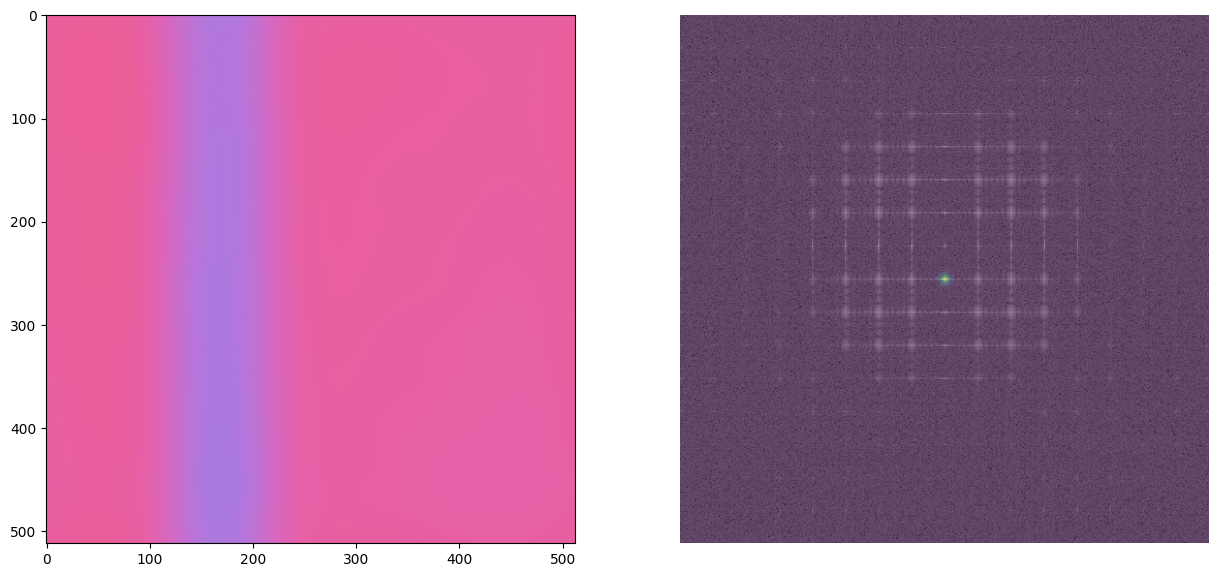

In [7]:
maskSize = 10
phaseA = gpa_object.calculate_phase_map(peakAPrecise,maskSize)
phaseB = gpa_object.calculate_phase_map(peakBPrecise,maskSize)

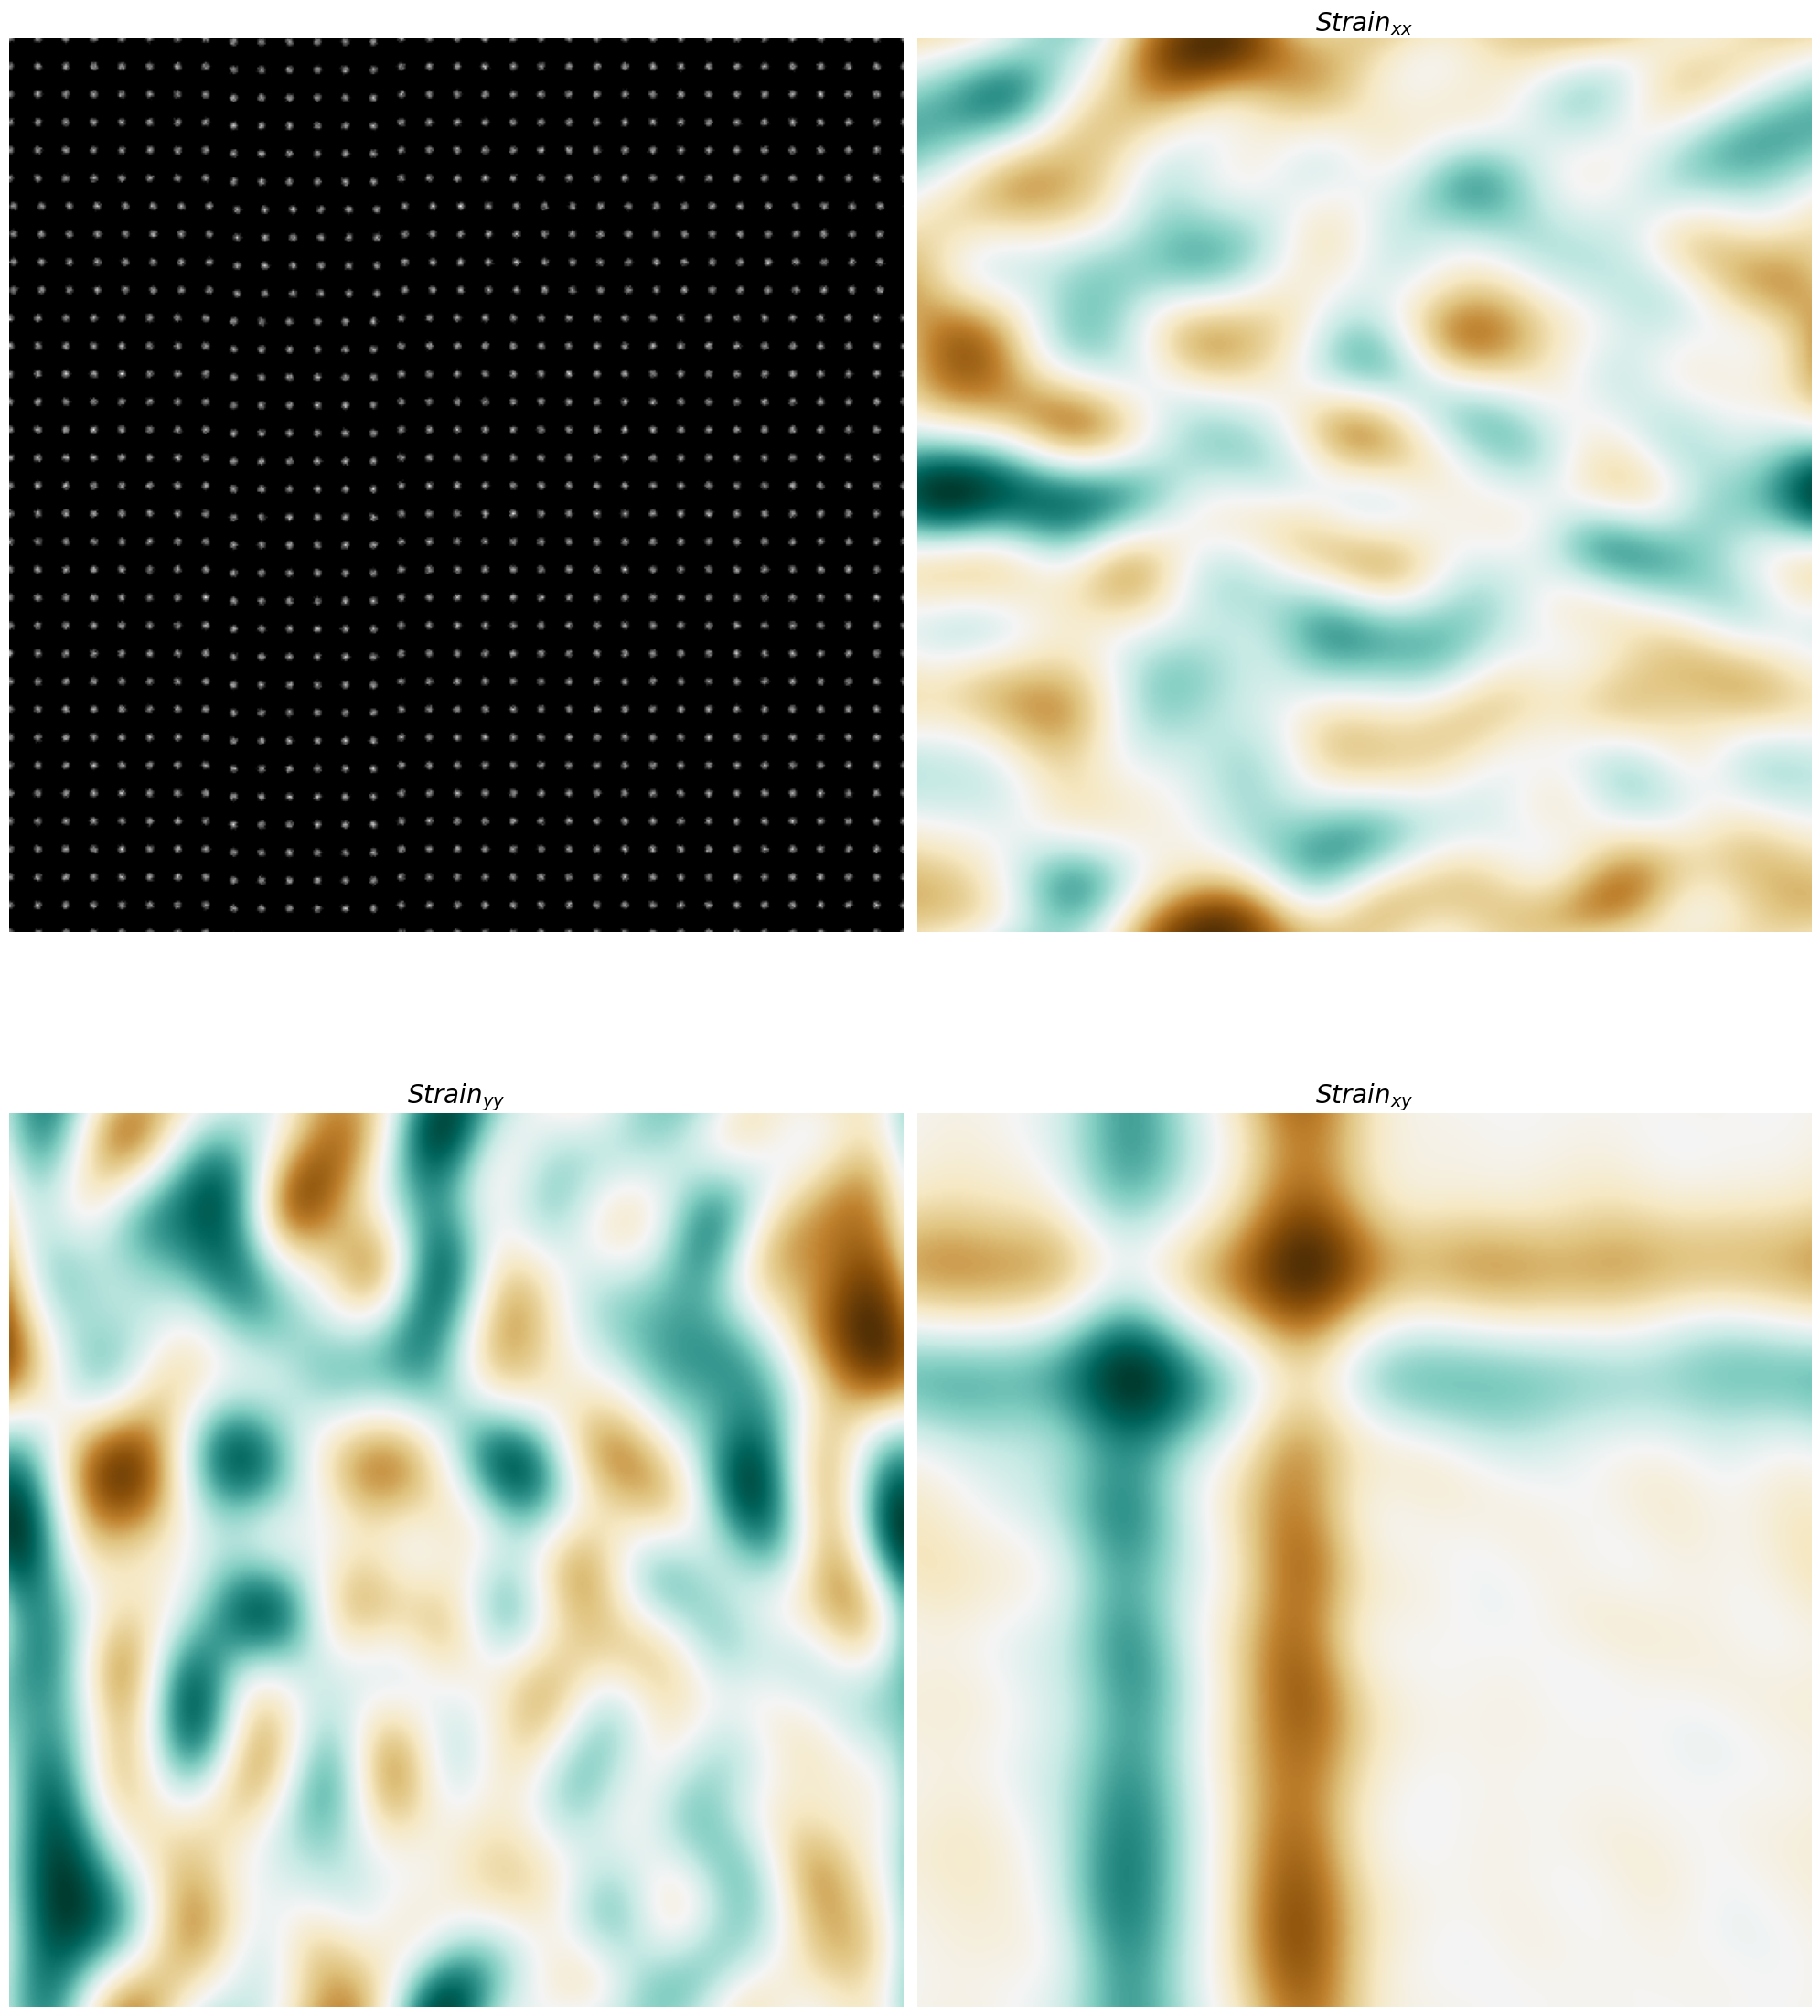

In [8]:
e_mat = gpa_object.calculate_strain_map_phase(peakAPrecise, peakBPrecise, phaseA, phaseB, showResult = True)

/home/wmill/COlab/Projects/20250709_quantEM/quantem/vquantem/lib/python3.12/site-packages/skimage/restoration/unwrap.py:103: ComplexWarning: Casting complex values to real discards the imaginary part
  image_not_masked = np.asarray(np.ma.getdata(image), dtype=np.float64, order='C')


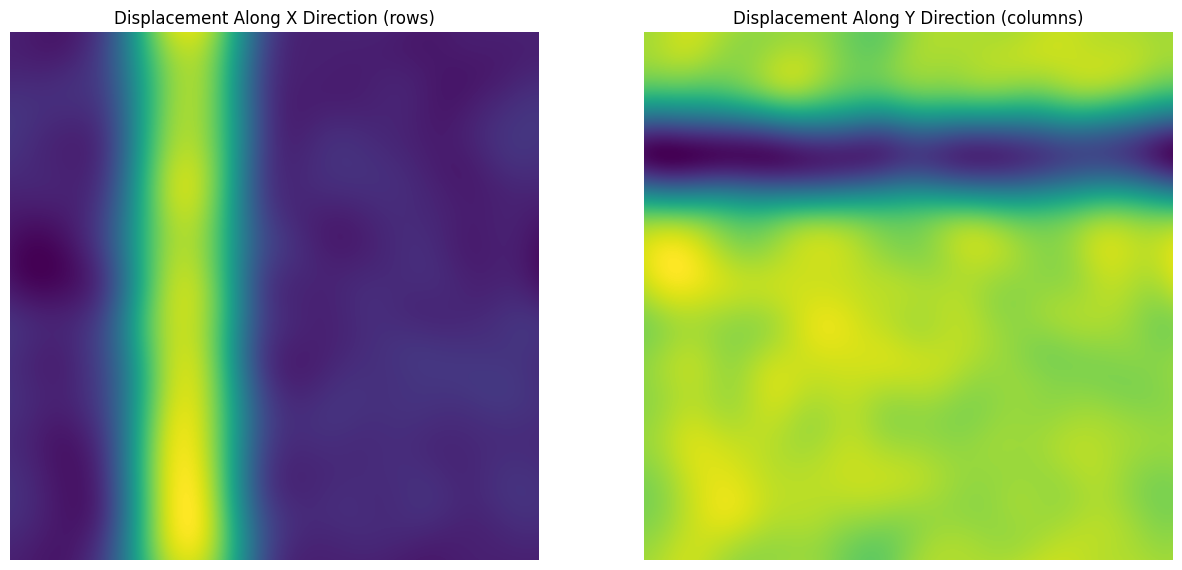

In [9]:
displacementA, displacementB = gpa_object.calculate_displacement_map(peakAPrecise, peakBPrecise, phaseA, phaseB, showResult = True)

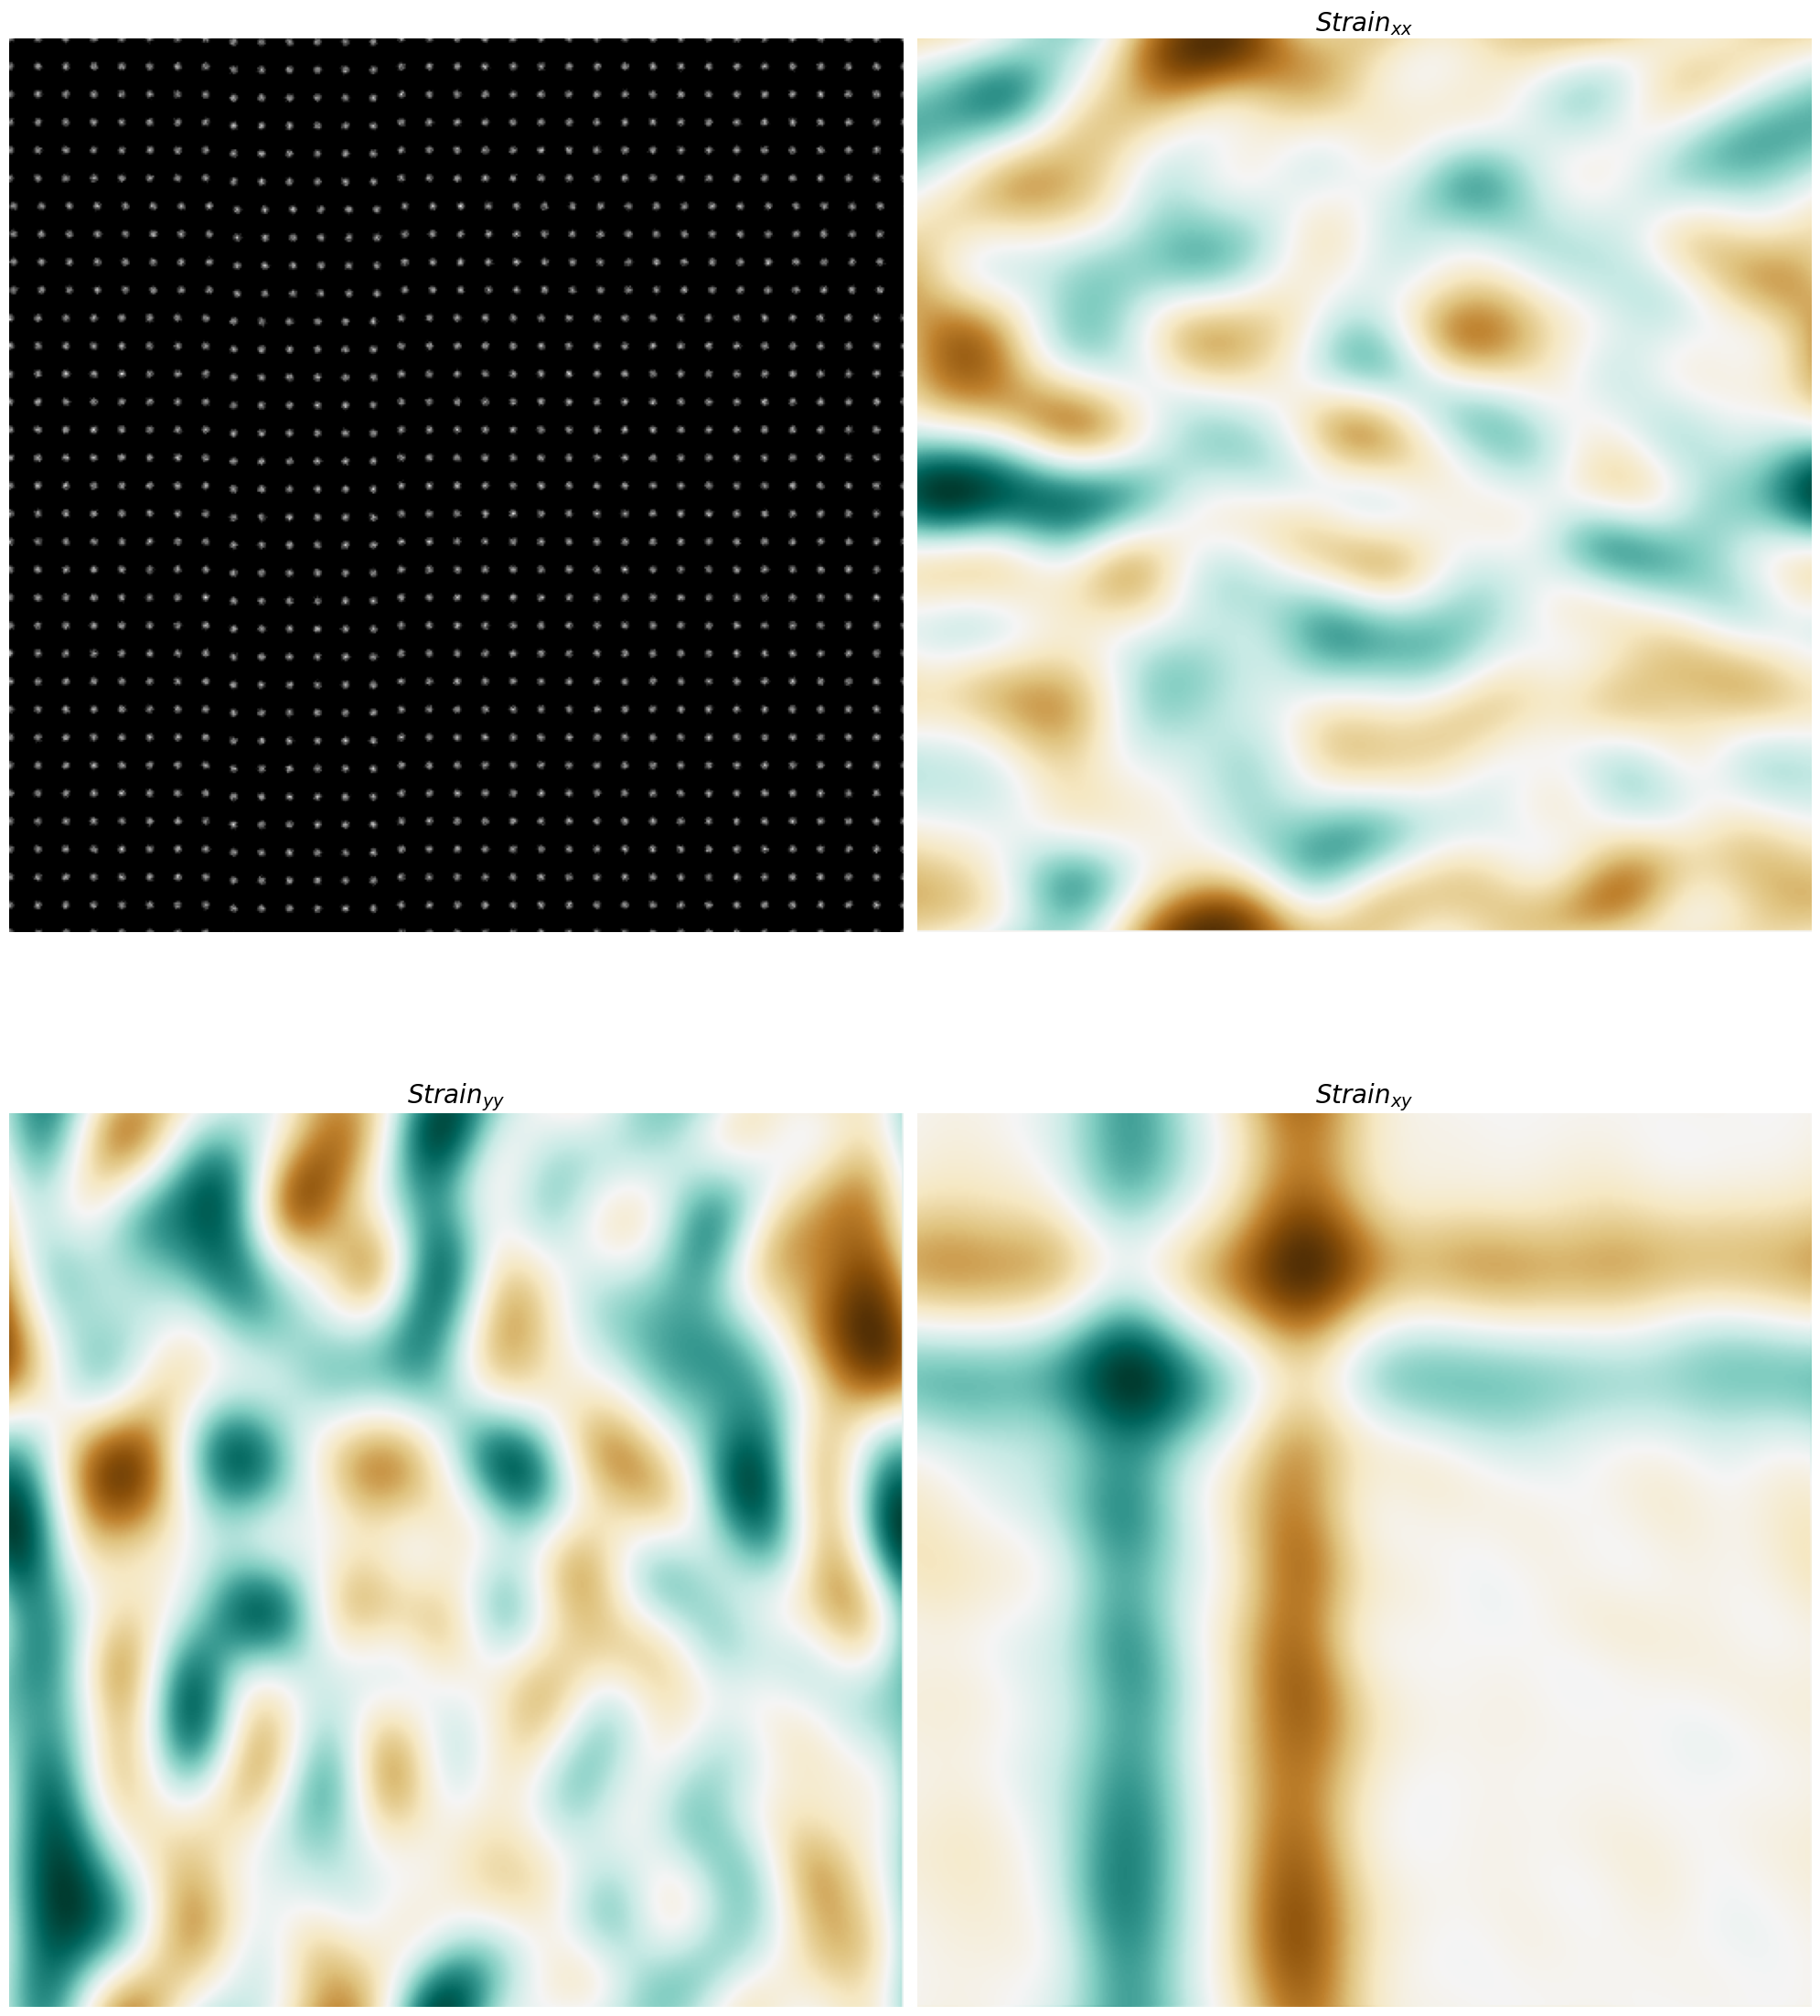

In [10]:
e_mat = gpa_object.calculate_strain_map(displacementA, displacementB)

## Refine Phase Maps

/home/wmill/COlab/Projects/20250709_quantEM/quantem/src/quantem/analysis/geometric_phase_analysis_2D.py:766: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  plt.annotate(A, (A[0]/self.nx, (1 - A[1]/self.ny)), textcoords='axes fraction', size=15,color='w')
/home/wmill/COlab/Projects/20250709_quantEM/quantem/src/quantem/analysis/geometric_phase_analysis_2D.py:767: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  plt.annotate(B, (B[0]/self.nx, (1 - B[1]/self.ny)), textcoords='axes fraction', size=15,color='w')
/home/wmill/COlab/Projects/20250709_quantEM/quantem/src/quantem/analysis/geometric_phase_analysis_2D.py:768: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  plt.annotate(C, (C[0]/self.nx, (1 - C[1]/self.ny)), textcoords='axes fraction', size=15,color='w')
/home/wmill/COlab/P

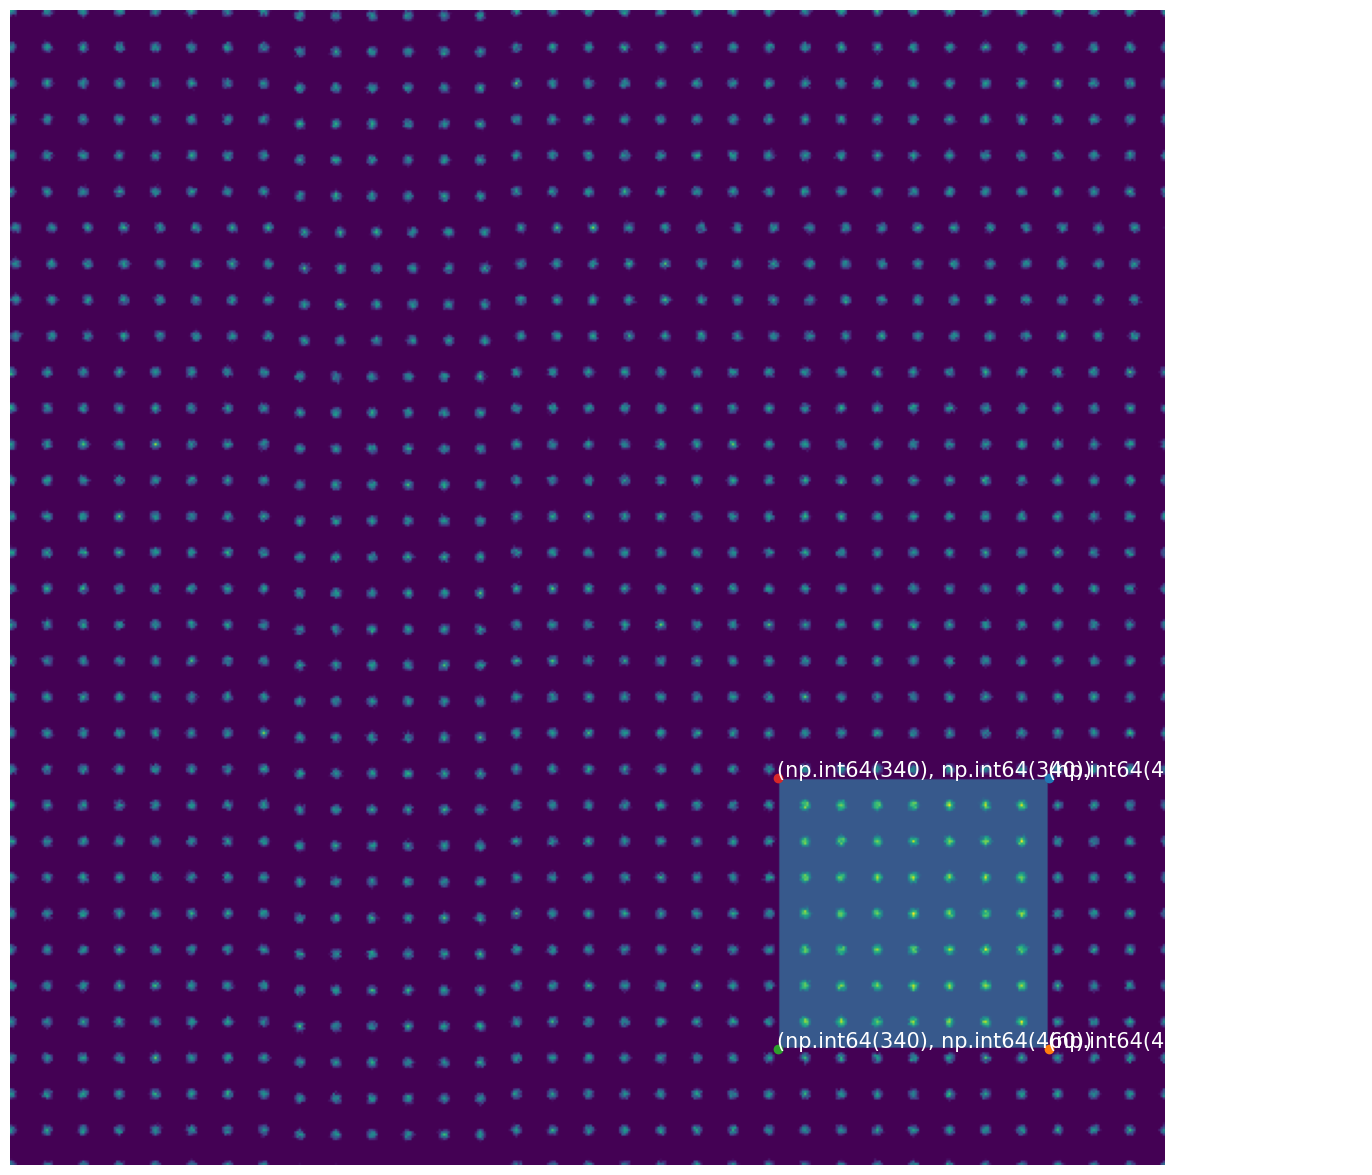

In [11]:
refMatrix = gpa_object.set_reference_matrix_s(np.array([400,400]), 60)

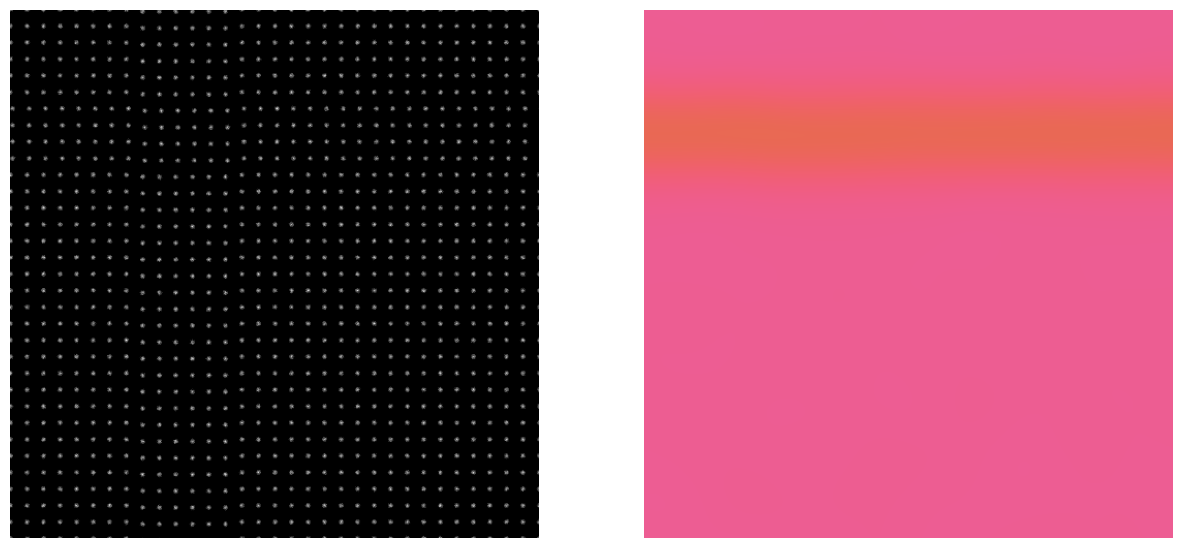

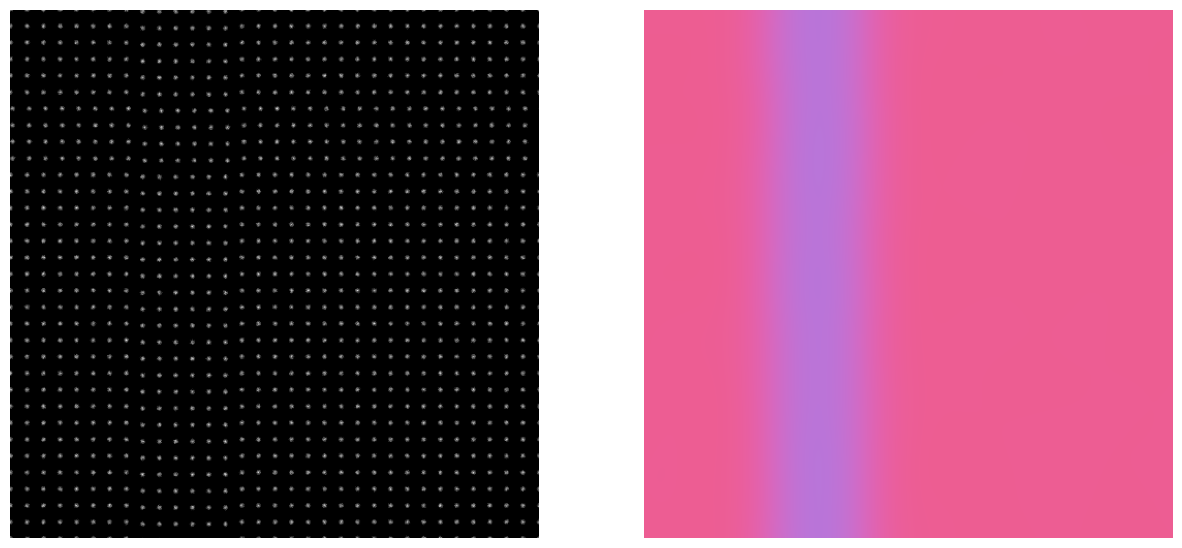

In [12]:
iterations = 25
useGaussMask = True
showResult = True
peakARefined, phaseARefined = gpa_object.refine_phase(phaseA, peakA, refMatrix, maskSize, iterations, useGaussMask, showResult)
peakBRefined, phaseBRefined = gpa_object.refine_phase(phaseB, peakB, refMatrix, maskSize, iterations, useGaussMask, showResult)